In [6]:
%matplotlib inline
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from search.save_data import DataSaver

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
})

EXPERIMENT_DIR_PATH = "./experiments"
TASK_PARAMETER_NAME = {"climb_box" : "height", "cross_gap" : "gap_length"}

In [7]:
def add_collision_free_stats(data):
    is_collision_free = [collision == 0 for collision in data["avg_collision"]]
    N_collision_free = sum(is_collision_free)
    collision_free_index = [i for i, collision_free in enumerate(is_collision_free) if collision_free]
    
    data["first_collision_free_it"] = int(np.argmax(is_collision_free))+1
    data["first_collision_free_time"] = data["search_time"][data["first_collision_free_it"]]
    data["is_collision_free"] = is_collision_free
    data["cum_sum_collision_free"] = np.cumsum(is_collision_free)
    data["collision_free_it"] = collision_free_index
    data["n_collision_free"] = N_collision_free
    data["avg_collision_free_per_it"] = N_collision_free / data["iteration"][-1]
    data["avg_collision_free_per_min"] = N_collision_free / (data["search_time"][-1] / 60)


def load_all_data_exp(experiment_dir, remove_seq: bool = True):
    all_rows = []
    for task_name in os.listdir(experiment_dir):
        exp_task_dir = os.path.join(experiment_dir, task_name)
        
        for param_name in os.listdir(exp_task_dir):
            exp_task_param_dir = os.path.join(exp_task_dir, param_name)
            
            for param_value_str in os.listdir(exp_task_param_dir):
                param_value_dir_path = os.path.join(exp_task_param_dir, param_value_str)
                param_value = float(param_value_str)
                for i_run, run_dir in enumerate(os.listdir(param_value_dir_path)):
                    run_dir_path = os.path.join(param_value_dir_path, run_dir)
                    data_run = DataSaver(run_dir_path).load()
                    add_collision_free_stats(data_run)

                    if remove_seq:
                        del data_run["sequence"]

                    row_base = {
                        "task_name": task_name,
                        "param_name" : param_name,
                        "param_value": param_value,
                        "run_index": i_run,
                    }

                    # Create one row per iteration if the value is list-like
                    max_len = max((len(v) for v in data_run.values() if isinstance(v, (list, np.ndarray))), default=0)
                    for it in range(max_len):
                        row = row_base.copy()
                        for k, v in data_run.items():
                            if isinstance(v, (list, np.ndarray)):
                                if it < len(v):
                                    row[k] = v[it]
                            else:
                                row[k] = v
                        row["iteration"] = it
                        all_rows.append(row)

                    print("Data", task_name, param_value, "run", i_run, "loaded!")

    return pd.DataFrame(all_rows)

data = load_all_data_exp(EXPERIMENT_DIR_PATH)


Data cross_gap 1.5 run 0 loaded!
Data cross_gap 1.5 run 1 loaded!
Data cross_gap 1.5 run 2 loaded!
Data cross_gap 1.5 run 3 loaded!
Data cross_gap 1.5 run 4 loaded!
Data cross_gap 1.3 run 0 loaded!
Data cross_gap 1.3 run 1 loaded!
Data cross_gap 1.3 run 2 loaded!
Data cross_gap 1.3 run 3 loaded!
Data cross_gap 1.3 run 4 loaded!
Data cross_gap 0.9 run 0 loaded!
Data cross_gap 0.9 run 1 loaded!
Data cross_gap 0.9 run 2 loaded!
Data cross_gap 0.9 run 3 loaded!
Data cross_gap 0.9 run 4 loaded!
Data cross_gap 0.5 run 0 loaded!
Data cross_gap 0.5 run 1 loaded!
Data cross_gap 0.5 run 2 loaded!
Data cross_gap 0.5 run 3 loaded!
Data cross_gap 0.5 run 4 loaded!
Data cross_gap 0.7 run 0 loaded!
Data cross_gap 0.7 run 1 loaded!
Data cross_gap 0.7 run 2 loaded!
Data cross_gap 0.7 run 3 loaded!
Data cross_gap 0.7 run 4 loaded!
Data cross_gap 1.1 run 0 loaded!
Data cross_gap 1.1 run 1 loaded!
Data cross_gap 1.1 run 2 loaded!
Data cross_gap 1.1 run 3 loaded!
Data cross_gap 1.1 run 4 loaded!
Data cross

In [12]:
def box_plot_param(df: pd.DataFrame,
                   stat_label: str,
                   task_name: str = "",
                   plot_type: str = "box",
                   title: str = "",
                   xlabel: str = "",
                   ylabel: str = "",
                   yscale: str = "linear",
                   fontsize: int = 12):
    
    VALID_PLOT_TYPE = ["box", "violin"]
    if plot_type not in VALID_PLOT_TYPE:
        raise ValueError(f"plot_type {plot_type} should be part of {VALID_PLOT_TYPE}")

    plt.figure(figsize=(5, 5))

    parameter_name = "parameter"
    if task_name:
        df = df[df["task_name"] == task_name]
        parameter_name = df["param_name"].iloc[0]

    
    if plot_type == "box":
        ax = sns.barplot(data=df, x="param_value", y=stat_label, log_scale=yscale=="log", errorbar="sd", color="gray")
        # ax.bar_label(ax.containers[0], fontsize=10)
    elif plot_type == "violin":
        sns.violinplot(data=df, x="param_value", y=stat_label, label=stat_label)
    
    stat_label = "search time (s)" if "time" in stat_label else stat_label
    parameter_name = parameter_name.replace("_", " ") + " (m)"
    plt.yscale(yscale)
    plt.xlabel(xlabel if xlabel else parameter_name, fontsize=fontsize)
    plt.ylabel(ylabel if ylabel else stat_label, fontsize=fontsize)
    plt.title(title if title else f"{stat_label} - {task_name}", fontsize=fontsize)
    plt.xticks(rotation=45, fontsize=fontsize)
    plt.yticks(fontsize=fontsize)
    plt.tight_layout()
    output_dir = f"figures/{task_name}/"
    os.makedirs(output_dir, exist_ok=True)
    output_path = os.path.join(output_dir, f"{task_name}_{stat_label.replace(" ", "_")}.pdf")
    plt.savefig(output_path, format="pdf")
    plt.show()


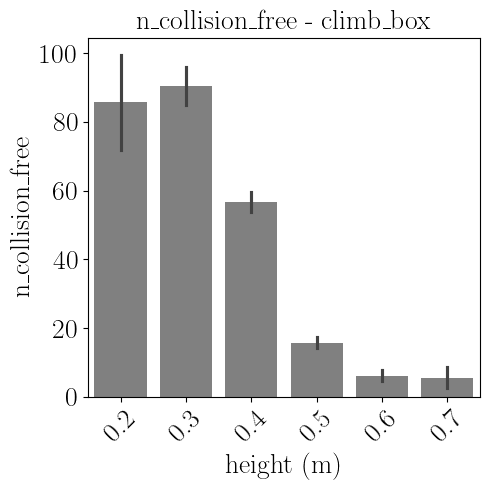

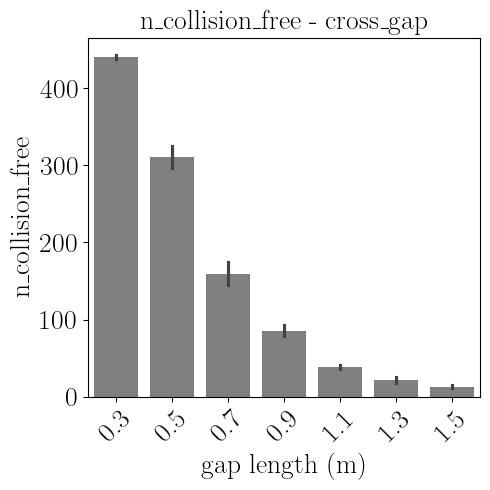

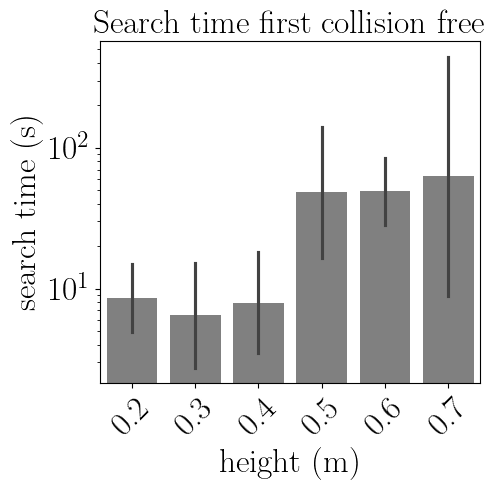

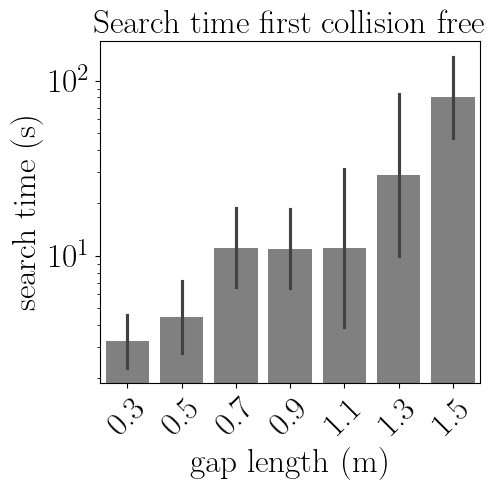

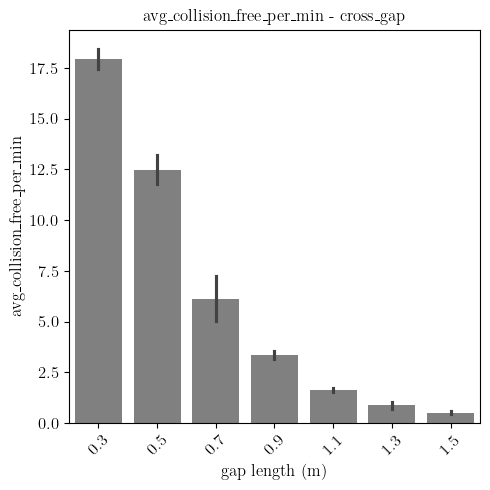

In [14]:
box_plot_param(data, "n_collision_free", "climb_box", plot_type="box", fontsize=20)
box_plot_param(data, "n_collision_free", "cross_gap", plot_type="box", fontsize=20)
box_plot_param(data, "first_collision_free_time", "climb_box", title="Search time first collision free", plot_type="box", yscale="log", fontsize=24)
box_plot_param(data, "first_collision_free_time", "cross_gap", title="Search time first collision free", plot_type="box", yscale="log", fontsize=24)
# box_plot_param(data, "first_collision_free_time", "climb_box", plot_type="box", yscale="log")
# box_plot_param(data, "first_collision_free_it", "climb_box", plot_type="box", yscale="log")
box_plot_param(data, "avg_collision_free_per_min", "cross_gap", plot_type="box")

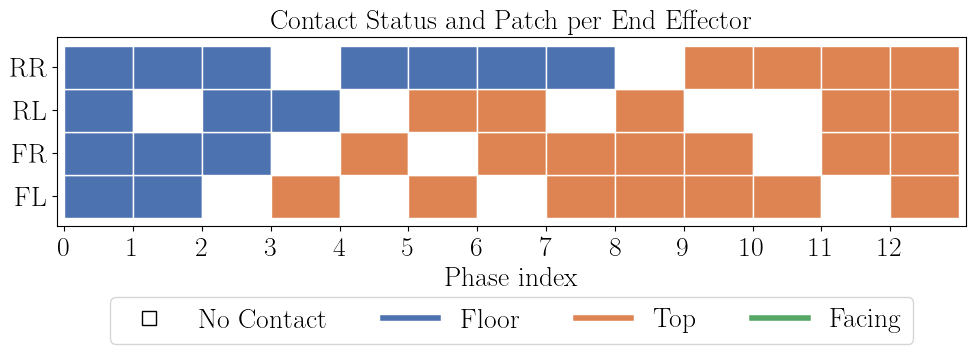

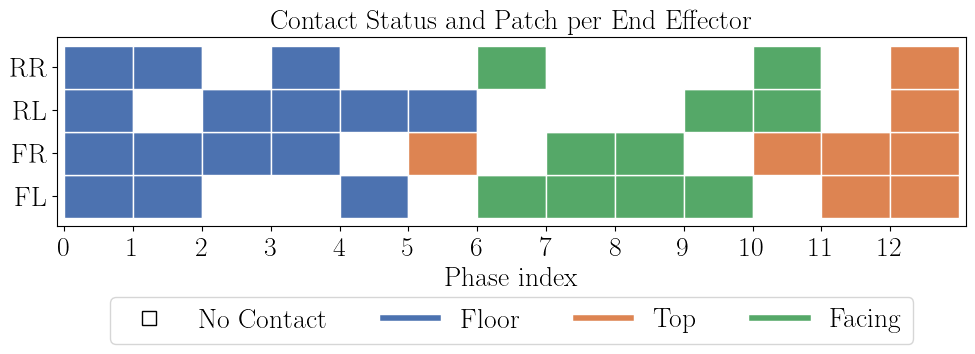

In [10]:
from search.utils.save import load_phase_sequence_from_yaml

PATCH_ID_2_NAME = {i : name for i, name in enumerate(["Floor", "Top", "Facing"])}
EEFF_ID_2_NAME = {i : name for i, name in enumerate(["FL", "FR", "RL", "RR"])}

def plot_contact_sequence(contact_sequence, task_name : str, fontsize: int = 12):
    """Visualize contact status per end-effector and contact patch transitions."""
    import matplotlib.colors as mcolors

    all_patches = list(range(len(PATCH_ID_2_NAME)))
    patch_to_color = {p: c for p, c in zip(all_patches, sns.color_palette("deep", n_colors=len(all_patches)))}

    num_effectors = len(contact_sequence[0][1])
    fig, ax = plt.subplots(figsize=(10, num_effectors))

    for (phase_id, contact_status, contact_patch) in contact_sequence:
        i_patch = 0
        for eff_id, status in enumerate(contact_status):
            color = 'white' if status == 0 else patch_to_color.get(contact_patch[i_patch], 'gray')
            ax.barh(y=eff_id, width=1, left=phase_id, height=1., color=color, edgecolor='white')
            i_patch += int(status)

    ax.set_yticks(range(num_effectors))
    ax.set_yticklabels([f"{EEFF_ID_2_NAME[i]}" for i in range(num_effectors)], fontsize=fontsize)
    ax.set_xticks(range(phase_id+1))
    ax.set_xticklabels([str(i) for i in range(phase_id+1)], fontsize=fontsize)
    ax.set_xlim(-0.1, len(contact_sequence)+0.1)

    ax.set_xlabel("Phase index", fontsize=fontsize)
    ax.set_title("Contact Status and Patch per End Effector", fontsize=fontsize)

    legend_handles = [plt.Line2D([0], [0], color=patch_to_color[p], lw=4, label=f"{PATCH_ID_2_NAME[p]}")
                      for p in all_patches]
    legend_handles.insert(0, plt.Line2D([0], [0], color='white', marker='s', markerfacecolor='white', markeredgecolor='black', markersize=10, lw=0, label='No Contact'))

    ax.legend(handles=legend_handles, bbox_to_anchor=(0.5, -0.3), loc='upper center', ncol=len(legend_handles), fontsize=fontsize)
    plt.tight_layout()
    
    output_dir = f"figures/{task_name}/"
    hash = sum([sum(cnt[1]) ** (cnt[0] + len(cnt[2])) for cnt in contact_sequence])
    os.makedirs(output_dir, exist_ok=True)
    output_path = os.path.join(output_dir, f"{task_name}_contact_plan_{hash}.pdf")
    plt.savefig(output_path, format="pdf")
    plt.show()

fontsize = 20

run_path = "/home/atari/workspace/experiments/climb_box/height/0.4/climb_box_2025-05-07_20-44-48/collision_free_iteration_14"
seq, n_nodes = load_phase_sequence_from_yaml(run_path)
plot_contact_sequence(seq, "climb_box", fontsize)
run_path = "/home/atari/workspace/experiments/climb_box/height/0.4/climb_box_2025-05-07_20-44-48/collision_free_iteration_125"
seq, n_nodes = load_phase_sequence_from_yaml(run_path)
plot_contact_sequence(seq, "climb_box", fontsize)

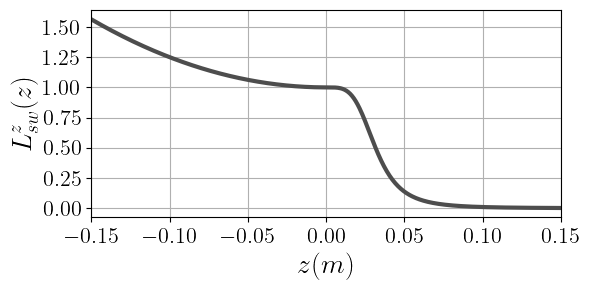

In [11]:
x = np.linspace(-0.15, 0.15, 500)  # Generate 500 points between -10 and 10
beta_p = 10e-7
beta_m = 5
y = (beta_p / (beta_p + x**4))
fontsize = 20

# y = np.where(x < 0, x**2 + 1, y)


y = (1 + np.sign(x))/2 * y + (1 - np.sign(x))/2 * ((beta_m*x)**2 + 1)

plt.figure(figsize=(6, 3))
plt.plot(x, y, color=[0.3, 0.3, 0.3], lw=3)
plt.xticks(fontsize=fontsize * 0.8)
plt.yticks(fontsize=fontsize * 0.8)
plt.xlim(-0.15, 0.15)
plt.xlabel("$z (m)$", fontsize=fontsize)
plt.ylabel("$L_{sw}^z(z)$", fontsize=fontsize)
plt.grid()
plt.tight_layout()
output_dir = "./figures/"
os.makedirs(output_dir, exist_ok=True)
output_path = os.path.join(output_dir, "Lswz_plot.pdf")
plt.savefig(output_path, format="pdf")